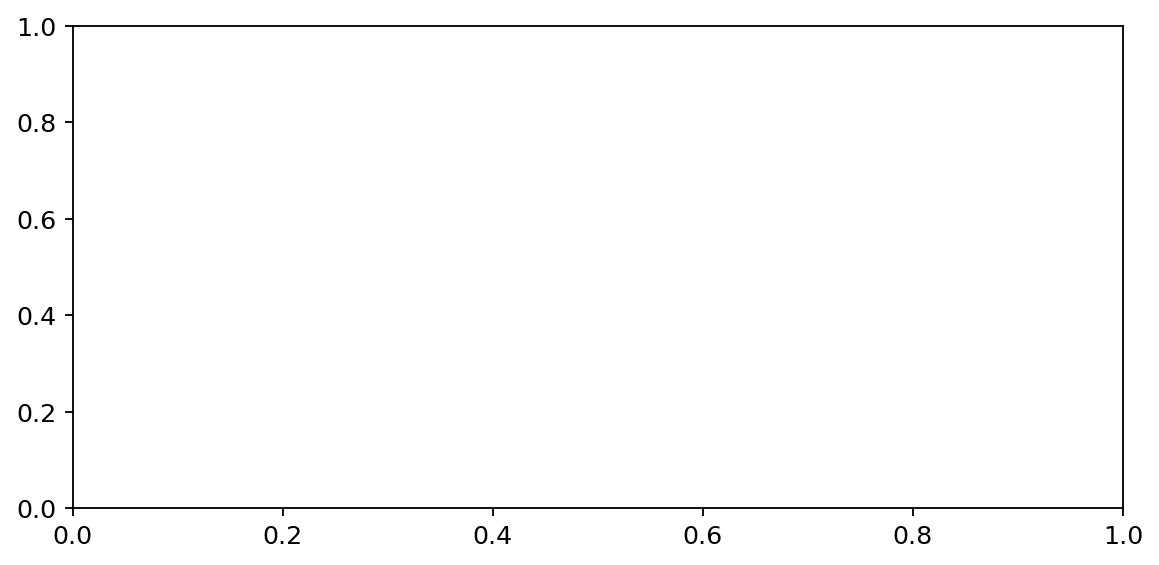

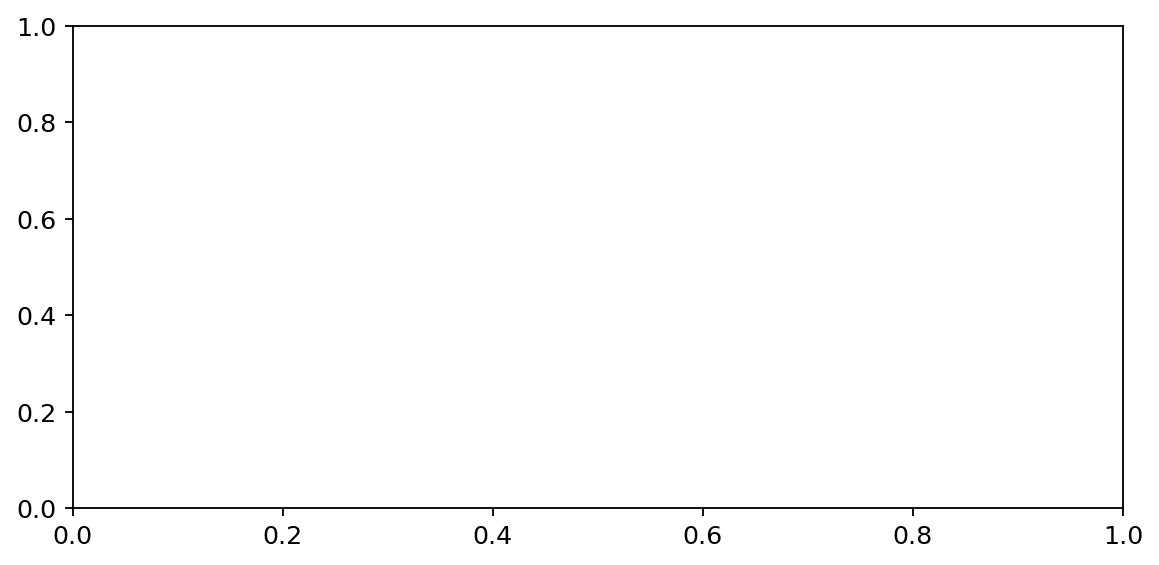

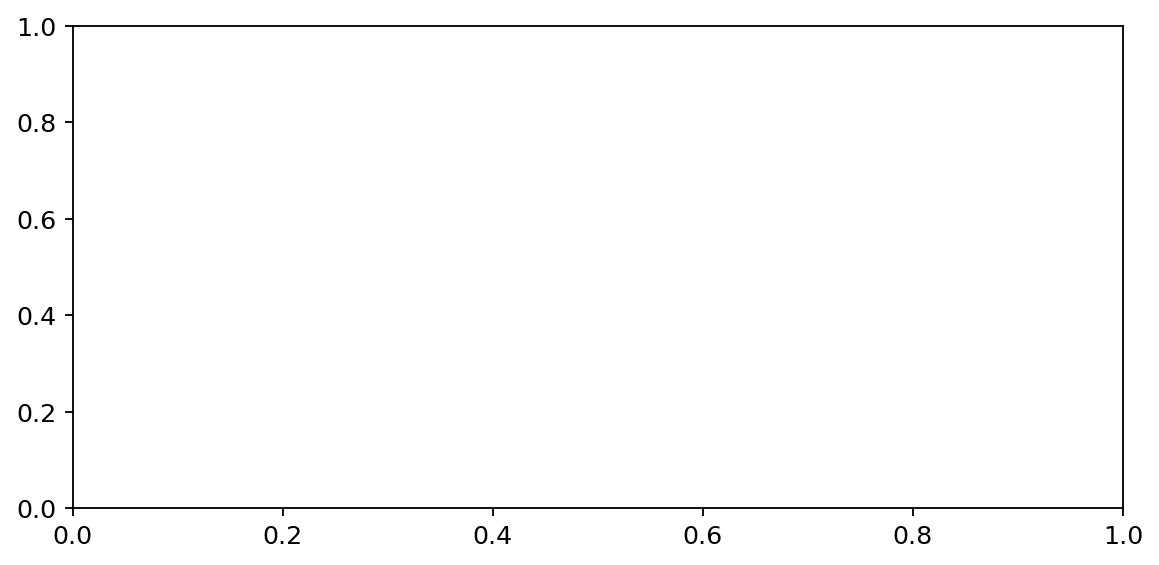

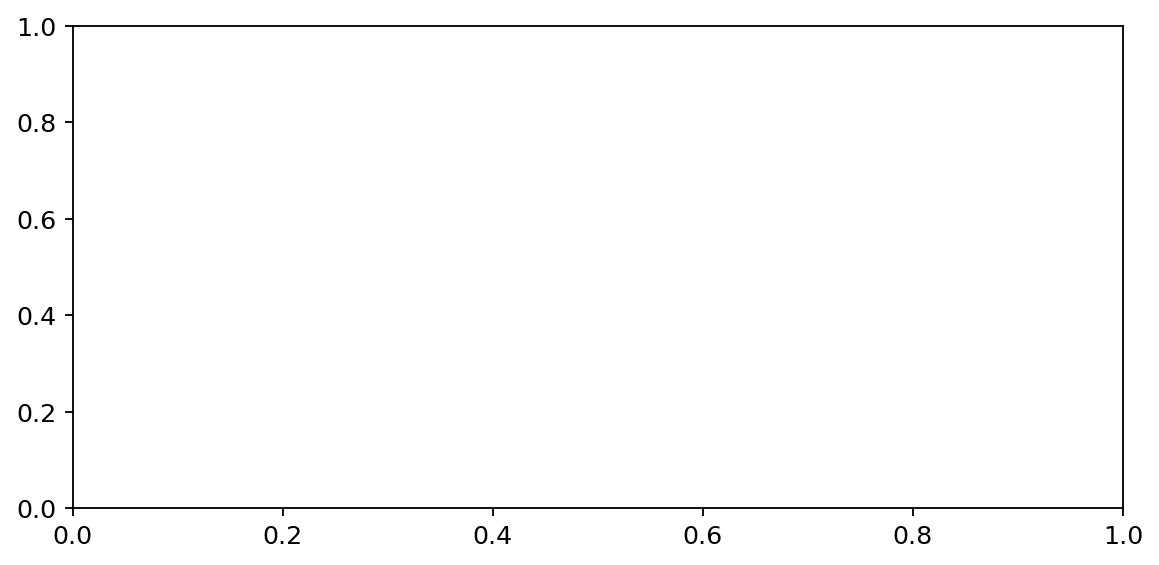

In [1]:
try:
    import wrds
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "wrds is missing in the current Python environment. "
        "Please install dependencies first: python -m pip install -r requirements.txt"
    ) from e
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import tkinter as tk
from tkinter import ttk, messagebox, scrolledtext
import numpy as np
import time
import random
import threading
import ctypes
import warnings
warnings.filterwarnings('ignore')

# CRSP field `dsf.shrout` is reported in thousands of shares.
# Market capitalization is computed as: absolute price * shrout * 1000.
SHROUT_MULTIPLIER = 1000

# ============================
# Utility: Temporary Success Popup
# ============================
# This helper creates a lightweight top-level window that closes automatically
# after a short delay. It is used as non-blocking feedback after export.
def auto_close_popup(title, msg, delay=3000):
    p = tk.Toplevel()
    p.title(title)
    p.geometry("320x100")
    tk.Label(p, text=msg, pady=20, font=("Arial",10)).pack()
    p.after(delay, p.destroy)

# ============================
# Industry Annual Benchmark (Course Scope)
# ============================
# Returns year-level benchmark statistics for a given SIC code from Compustat
# fundamentals with the required class filters.
def get_industry_avg(sic_code, WRDS_USERNAME, WRDS_PASSWORD):
    if sic_code is None or pd.isna(sic_code):
        return pd.DataFrame()

    db = None
    try:
        sic_code = int(float(sic_code))
        db = wrds.Connection(wrds_username=WRDS_USERNAME, wrds_password=WRDS_PASSWORD)

        ind_df = db.raw_sql("""
            SELECT fyear,
                   sich AS sic_code,
                   COUNT(*) AS num_obs,
                   AVG(sale) AS avg_sale,
                   AVG(at) AS avg_total_assets,
                   AVG(ceq) AS avg_common_equity
            FROM comp.funda
            WHERE sich = %s
            AND fyear BETWEEN 2015 AND 2024
            AND datafmt = 'STD'
            AND consol = 'C'
            AND indfmt = 'INDL'
            GROUP BY fyear, sich
            ORDER BY fyear
        """, params=(sic_code,))

        return ind_df.round(2)

    except Exception:
        return pd.DataFrame()
    finally:
        if db is not None:
            try:
                db.close()
            except Exception:
                pass

# ============================
# Runtime Configuration
# ============================
# User agent list is kept for parity with your original structure.
# WRDS queries in this script are database calls and do not rely on HTTP headers.
USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 6.1, x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/118.0.0.0 Safari/537.36",
]
def apply_random_user_agent():
    # Kept as a placeholder for extensibility.
    headers = {"User-Agent": random.choice(USER_AGENTS)}
def random_delay():
    # Small delay between quarter queries to reduce burst load.
    time.sleep(random.uniform(1.2, 2.5))

plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11


def render_single_series_chart(ax, df, x_col, y_col, title, y_label, color, is_currency=False, currency_divisor=1e9, marker=False):
    ax.clear()
    ax.set_axis_on()
    ax.set_facecolor("white")
    if df is None or df.empty or x_col not in df.columns or y_col not in df.columns:
        ax.set_title(title, fontsize=11, pad=5, loc="left")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, fontsize=13)
        return

    clean_df = df[[x_col, y_col]].copy()
    if x_col.lower().endswith("date") or x_col.lower() in {"date", "datadate"}:
        clean_df[x_col] = pd.to_datetime(clean_df[x_col], errors="coerce")
    else:
        clean_df[x_col] = pd.to_numeric(clean_df[x_col], errors="coerce")
    clean_df[y_col] = pd.to_numeric(clean_df[y_col], errors="coerce")
    clean_df = clean_df.dropna()
    if clean_df.empty:
        ax.set_title(title, fontsize=11, pad=5, loc="left")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, fontsize=13)
        return

    ax.plot(clean_df[x_col], clean_df[y_col], color=color, linewidth=2.3, marker="o" if marker else None)
    ax.set_title(title, fontsize=11, pad=5, loc="left")
    ax.set_ylabel(y_label, fontsize=13)
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.grid(alpha=0.3, linestyle="--")
    if is_currency:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x / currency_divisor:.1f}B"))
    ax.figure.tight_layout(pad=0.9, rect=(0, 0, 1, 0.93))


def build_metric_combo(parent, label_text, values, default_value):
    bg = parent.cget("bg") if "bg" in parent.keys() else "#F5F6F8"
    wrapper = tk.Frame(parent, bg=bg)
    wrapper.pack(fill=tk.X, pady=(0, 6))
    tk.Label(wrapper, text=label_text, bg=bg, fg="#374151").pack(anchor="w")
    var = tk.StringVar(value=default_value)
    combo = ttk.Combobox(wrapper, textvariable=var, state="readonly", values=values, width=24)
    combo.pack(anchor="w", fill=tk.X)
    return var, combo


def bind_responsive_canvas(container, figure, canvas):
    """Resize the Matplotlib figure to match the Tk container."""
    def on_resize(event):
        if event.width <= 1 or event.height <= 1:
            return
        dpi = figure.dpi
        figure.set_size_inches(max(6.0, event.width / dpi), max(3.0, event.height / dpi), forward=True)
        canvas.draw_idle()

    container.bind("<Configure>", on_resize)

# ============================
# Company Lookup (Ticker + SIC)
# ============================
# Tries Compustat funda first (latest valid record), then falls back to
# comp.company SIC when no funda row is available.
def get_company_info(ticker, WRDS_USERNAME, WRDS_PASSWORD):
    db = None
    try:
        db = wrds.Connection(wrds_username=WRDS_USERNAME, wrds_password=WRDS_PASSWORD)
        sql = """
            SELECT tic, conm, sich
            FROM comp.funda
            WHERE UPPER(tic) = UPPER(%s)
            AND datafmt = 'STD' AND consol = 'C' AND indfmt = 'INDL'
            AND sich IS NOT NULL
            ORDER BY datadate DESC NULLS LAST, fyear DESC NULLS LAST
            LIMIT 1
        """
        df = db.raw_sql(sql, params=(ticker,))

        if df.empty:
            sql_fallback = """
                SELECT tic, conm, sic AS sich
                FROM comp.company
                WHERE UPPER(tic) = UPPER(%s)
                AND sic IS NOT NULL
                LIMIT 1
            """
            df = db.raw_sql(sql_fallback, params=(ticker,))

        return df
    except Exception as e:
        return pd.DataFrame()
    finally:
        if db is not None:
            try:
                db.close()
            except Exception:
                pass

# ============================
# Daily Stock Data (CRSP)
# ============================
# Pulls selected-year daily pricing/return/volume/share-outstanding data.
# The function updates chart data incrementally by quarter.
def get_year_quarters(year):
    """Split a calendar year into four query windows."""
    return [(f"{year}-01-01",f"{year}-03-31"),(f"{year}-04-01",f"{year}-06-30"),(f"{year}-07-01",f"{year}-09-30"),(f"{year}-10-01",f"{year}-12-31")]

def get_single_year_daily(ticker, year, status_label, update_ui_callback, WRDS_USERNAME, WRDS_PASSWORD, stop_event=None):
    """
    Query CRSP daily data for one ticker and one year.

    Parameters
    ----------
    ticker : str
        Target security ticker.
    year : str
        Target year (YYYY).
    status_label : tk.Label
        UI label for progress feedback.
    update_ui_callback : callable
        Callback for incremental chart refresh.
    WRDS_USERNAME / WRDS_PASSWORD : str
        Runtime user credentials entered in GUI.
    stop_event : threading.Event | None
        Cooperative stop flag used when window is closing.
    """
    apply_random_user_agent()
    if stop_event is not None and stop_event.is_set():
        return pd.DataFrame()
    quarters = get_year_quarters(year)
    all_data = []
    status_label.config(text=f"Fetching {ticker} daily data...")
    status_label.update()
    db = None
    try:
        db = wrds.Connection(wrds_username=WRDS_USERNAME, wrds_password=WRDS_PASSWORD)
        permno_sql = "SELECT DISTINCT permno FROM crsp.stocknames WHERE UPPER(ticker)=UPPER(%s) LIMIT 1"
        permno_df = db.raw_sql(permno_sql, params=(ticker,))
        if permno_df.empty:
            status_label.config(text="Stock not found")
            return pd.DataFrame()
        permno = int(permno_df.iloc[0]["permno"])
    except Exception:
        status_label.config(text="WRDS connect fail")
        return pd.DataFrame()
    finally:
        if db is not None:
            try:
                db.close()
            except Exception:
                pass

    for i,(s,e) in enumerate(quarters):
        if stop_event is not None and stop_event.is_set():
            return pd.DataFrame()
        status_label.config(text=f"Quarter {i+1}/4")
        status_label.update()
        db = None
        try:
            db = wrds.Connection(wrds_username=WRDS_USERNAME, wrds_password=WRDS_PASSWORD)
            sql = f"SELECT date, prc, ret, vol, shrout FROM crsp.dsf WHERE permno={permno} AND date>='{s}' AND date<='{e}' ORDER BY date"
            df_q = db.raw_sql(sql, date_cols=["date"])
            if not df_q.empty:
                all_data.append(df_q)
                temp_df = pd.concat(all_data, ignore_index=True)
                temp_df["close"] = temp_df["prc"].abs()
                temp_df["volume"] = temp_df["vol"]
                # `shrout` is in thousands, so convert to actual shares.
                temp_df["market_cap"] = (temp_df["close"] * temp_df["shrout"].fillna(0) * SHROUT_MULTIPLIER).round(2)
                update_ui_callback(temp_df)
        except Exception:
            pass
        finally:
            if db is not None:
                try:
                    db.close()
                except Exception:
                    pass
        random_delay()

    if not all_data:
        return pd.DataFrame()
    df = pd.concat(all_data, ignore_index=True)
    df["close"] = df["prc"].abs()
    df["daily_return"] = df["ret"]
    df["volume"] = df["vol"]
    # Final market cap uses the same conversion logic as incremental updates.
    df["market_cap"] = (df["close"] * df["shrout"].fillna(0) * SHROUT_MULTIPLIER).round(2)
    return df[["date","close","daily_return","volume","market_cap"]].round(4).sort_values("date").drop_duplicates()

# ============================
# Financial Statement + DuPont Metrics
# ============================
# Pulls annual fundamentals and computes DuPont decomposition components.
def get_financial_data(ticker, status_label, WRDS_USERNAME, WRDS_PASSWORD):
    apply_random_user_agent()
    status_label.config(text="Loading financial & DuPont...")
    status_label.update()
    db = None
    try:
        db = wrds.Connection(wrds_username=WRDS_USERNAME, wrds_password=WRDS_PASSWORD)
        sql = """
        SELECT gvkey, tic, conm, datadate, ni, sale, at, ceq, lt, ebit, pi,
        ROUND(ni/sale,4) as profit_margin, ROUND(sale/at,4) as asset_turnover,
        ROUND(at/ceq,4) as equity_multiplier, ROUND((ni/sale)*(sale/at)*(at/ceq),4) as roe_dupont
        FROM comp.funda
        WHERE UPPER(tic)=UPPER(%s) AND datadate>='2015-01-01' AND datadate<='2024-12-31'
        AND sale>0 AND at>0 AND ceq>0 ORDER BY datadate;
        """
        df = db.raw_sql(sql, params=(ticker,), date_cols=["datadate"])
        rename = {"tic":"Ticker","conm":"Company","datadate":"Date","ni":"NetIncome","sale":"Revenue",
                  "at":"TotalAssets","lt":"TotalLiabs","ceq":"TotalEquity","ebit":"EBIT","pi":"PretaxIncome","profit_margin":"ProfitMargin",
                  "asset_turnover":"AssetTurnover","equity_multiplier":"EqMultiplier","roe_dupont":"ROE_DuPont"}
        out_df = df.rename(columns=rename)

        for required_col in [
            "NetIncome",
            "Revenue",
            "TotalAssets",
            "TotalLiabs",
            "TotalEquity",
            "EBIT",
            "PretaxIncome",
            "ProfitMargin",
            "AssetTurnover",
            "EqMultiplier",
            "ROE_DuPont",
        ]:
            if required_col not in out_df.columns:
                out_df[required_col] = pd.NA

        # Add robust extended metrics using existing fields only.
        def safe_div(numerator_col, denominator_col):
            numerator = pd.to_numeric(out_df.get(numerator_col), errors="coerce")
            denominator = pd.to_numeric(out_df.get(denominator_col), errors="coerce")
            denominator = denominator.replace(0, pd.NA)
            return numerator / denominator

        out_df["ROA"] = safe_div("NetIncome", "TotalAssets")
        out_df["DebtRatio"] = safe_div("TotalLiabs", "TotalAssets")
        out_df["DebtToEquity"] = safe_div("TotalLiabs", "TotalEquity")
        out_df["EquityRatio"] = safe_div("TotalEquity", "TotalAssets")
        out_df["CapitalIntensity"] = safe_div("TotalAssets", "Revenue")
        out_df["LiabilityToRevenue"] = safe_div("TotalLiabs", "Revenue")
        out_df["EBITMargin"] = safe_div("EBIT", "Revenue")
        out_df["PretaxMargin"] = safe_div("PretaxIncome", "Revenue")
        out_df["TaxBurden"] = safe_div("NetIncome", "PretaxIncome")
        out_df["InterestBurden"] = safe_div("PretaxIncome", "EBIT")
        out_df["EBITToAssets"] = safe_div("EBIT", "TotalAssets")

        # ROC uses TotalEquity + TotalLiabs as a simple capital base.
        capital_base = (
            pd.to_numeric(out_df.get("TotalEquity"), errors="coerce")
            + pd.to_numeric(out_df.get("TotalLiabs"), errors="coerce")
        )
        capital_base = capital_base.replace(0, pd.NA)
        out_df["ROC"] = pd.to_numeric(out_df.get("NetIncome"), errors="coerce") / capital_base

        return out_df
    except Exception:
        return pd.DataFrame()
    finally:
        if db is not None:
            try:
                db.close()
            except Exception:
                pass

# ============================
# Desktop GUI Application
# ============================
class StockAnalysisApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Max Finance")
        self.ui_bg = "#ECEFF3"
        self.panel_bg = "#F5F6F8"
        self.title_fg = "#1F2937"
        self.text_fg = "#374151"
        self.root.configure(bg=self.ui_bg)
        self.configure_ui_scale()
        self.root.geometry("1400x920")
        self.root.resizable(True,True)

        self.stock_df = None
        self.info_df = None
        self.financial_df = None
        self.industry_df = None
        self.current_sic = None
        self.industry_error = ""
        self.stop_event = threading.Event()
        self.query_thread = None
        self.stock_metric_var = None
        self.financial_metric_var = None
        self.dupont_metric_var = None
        self.industry_metric_var = None
        self.stock_chart_ax = None
        self.financial_chart_ax = None
        self.dupont_chart_ax = None
        self.industry_chart_ax = None
        self.stock_chart_canvas = None
        self.financial_chart_canvas = None
        self.dupont_chart_canvas = None
        self.industry_chart_canvas = None
        self.main_canvas = None
        self.main_scrollbar = None
        self.main_frame = None
        self.main_window_id = None

        self.root.protocol("WM_DELETE_WINDOW", self.on_close)

        # Centered credential + input control panel.
        controls_shell = tk.Frame(root, padx=15, pady=8, bg=self.ui_bg)
        controls_shell.pack(fill=tk.X)
        controls_panel = tk.Frame(controls_shell, padx=18, pady=12, bg=self.panel_bg)
        controls_panel.pack(anchor="center")

        tk.Label(controls_panel, text="Username:", bg=self.panel_bg, fg=self.text_fg).grid(row=0, column=0, padx=(4, 8), pady=4, sticky="e")
        self.wrds_user = tk.Entry(controls_panel, width=20)
        self.wrds_user.grid(row=0, column=1, padx=(0, 4), pady=4)

        tk.Label(controls_panel, text="Password:", bg=self.panel_bg, fg=self.text_fg).grid(row=1, column=0, padx=(4, 8), pady=4, sticky="e")
        self.wrds_pwd = tk.Entry(controls_panel, width=20, show="*")
        self.wrds_pwd.grid(row=1, column=1, padx=(0, 4), pady=4)

        tk.Label(controls_panel, text="Ticker:", bg=self.panel_bg, fg=self.text_fg).grid(row=2, column=0, padx=(4, 8), pady=4, sticky="e")
        self.entry_ticker = tk.Entry(controls_panel, width=20)
        self.entry_ticker.grid(row=2, column=1, padx=(0, 4), pady=4)

        tk.Label(controls_panel, text="Year:", bg=self.panel_bg, fg=self.text_fg).grid(row=3, column=0, padx=(4, 8), pady=4, sticky="e")
        self.year_var = tk.StringVar(value="2024")
        self.year_combo = ttk.Combobox(controls_panel, textvariable=self.year_var, state="readonly", width=18)
        self.year_combo["values"] = tuple(str(y) for y in range(2015, 2025))
        self.year_combo.grid(row=3, column=1, padx=(0, 4), pady=4, sticky="w")

        button_row = tk.Frame(controls_panel, bg=self.panel_bg)
        button_row.grid(row=4, column=0, columnspan=2, pady=(8, 2))
        self.btn_query = ttk.Button(button_row, text="Search", command=self.start_query)
        self.btn_query.pack(side=tk.LEFT, padx=6)
        self.btn_download = ttk.Button(button_row, text="Download", command=self.download_data)
        self.btn_download.pack(side=tk.LEFT, padx=6)

        self.status_label = tk.Label(root, text="Ready", fg="#4B5563", bg=self.ui_bg)
        self.status_label.pack(pady=2)

        self.main_canvas = tk.Canvas(root, highlightthickness=0, borderwidth=0, bg=self.ui_bg)
        self.main_scrollbar = ttk.Scrollbar(root, orient="vertical", command=self.main_canvas.yview)
        self.main_canvas.configure(yscrollcommand=self.main_scrollbar.set)
        self.main_scrollbar.pack(side=tk.RIGHT, fill=tk.Y)
        self.main_canvas.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=15, pady=8)

        self.main_frame = tk.Frame(self.main_canvas, bg=self.ui_bg)
        self.main_window_id = self.main_canvas.create_window((0, 0), window=self.main_frame, anchor="nw")
        self.main_frame.bind("<Configure>", lambda event: self.main_canvas.configure(scrollregion=self.main_canvas.bbox("all")))
        self.main_canvas.bind("<Configure>", self._sync_main_canvas_width)
        self._bind_mousewheel_scroll()

        self._build_dashboard_tabs()

    def configure_ui_scale(self):
        # Enable DPI awareness so Tk widgets stay legible on high-resolution displays.
        try:
            ctypes.windll.shcore.SetProcessDpiAwareness(2)
        except Exception:
            try:
                ctypes.windll.user32.SetProcessDPIAware()
            except Exception:
                pass

        try:
            dpi = ctypes.windll.user32.GetDpiForSystem()
        except Exception:
            dpi = self.root.winfo_fpixels("1i")

        try:
            scale = max(1.45, min(2.2, dpi / 96.0 * 1.35))
            self.root.tk.call("tk", "scaling", scale)
        except Exception:
            self.root.tk.call("tk", "scaling", 1.6)

        base_font = ("Segoe UI", 12)
        self.root.option_add("*Font", base_font)

        style = ttk.Style(self.root)
        try:
            style.theme_use("clam")
        except Exception:
            pass
        style.configure("TLabel", font=base_font, background=self.panel_bg, foreground=self.text_fg)
        style.configure("TButton", font=base_font, padding=7, background="#DDE2E8", foreground="#111827")
        style.map(
            "TButton",
            background=[("active", "#CBD5E1")],
            foreground=[("active", "#111827")],
        )
        style.configure("TCombobox", font=base_font, fieldbackground="#FFFFFF")
        style.configure("TNotebook", background=self.root.cget("bg"), borderwidth=0)
        style.configure("TNotebook.Tab", padding=(14, 8), font=("Segoe UI", 11))
        style.map(
            "TNotebook.Tab",
            background=[("selected", "#FFFFFF"), ("active", "#E9EEF5")],
            foreground=[("selected", "#111827"), ("active", "#111827")],
        )

    def _build_dashboard_tabs(self):
        # Stock section.
        stock_section = tk.Frame(self.main_frame, bg=self.panel_bg)
        stock_section.pack(fill=tk.X, padx=0, pady=(0, 18))
        self._make_section_title(stock_section, "1. Stock Data Visualization")
        stock_ctrl = tk.Frame(stock_section, bg=self.panel_bg)
        stock_ctrl.pack(fill=tk.X, padx=0, pady=(8, 4))
        self.stock_metric_var, stock_combo = build_metric_combo(
            stock_ctrl,
            "Select one stock metric",
            ["Market Cap", "Close", "Daily Return", "Volume"],
            "Market Cap",
        )
        stock_combo.bind("<<ComboboxSelected>>", self.on_stock_metric_change)
        self.stock_chart_frame = tk.Frame(stock_section, bg=self.panel_bg)
        self.stock_chart_frame.pack(fill=tk.X, padx=0, pady=(0, 8))
        self.stock_fig, self.stock_chart_ax = plt.subplots(figsize=(11.8, 4.6), dpi=100)
        self.stock_chart_canvas = FigureCanvasTkAgg(self.stock_fig, master=self.stock_chart_frame)
        self.stock_chart_canvas.get_tk_widget().configure(height=380)
        self.stock_chart_canvas.get_tk_widget().pack(fill=tk.X)

        # Financial section.
        fin_section = tk.Frame(self.main_frame, bg=self.panel_bg)
        fin_section.pack(fill=tk.X, padx=0, pady=(0, 18))
        self._make_section_title(fin_section, "2. Financial Data Visualization")
        fin_ctrl = tk.Frame(fin_section, bg=self.panel_bg)
        fin_ctrl.pack(fill=tk.X, padx=0, pady=(8, 4))
        self.financial_metric_var, fin_combo = build_metric_combo(
            fin_ctrl,
            "Select one reported fundamentals metric",
            ["Revenue", "Net Income", "EBIT", "Pretax Income", "Total Assets", "Total Liabilities", "Total Equity"],
            "Revenue",
        )
        fin_combo.bind("<<ComboboxSelected>>", self.on_financial_metric_change)
        self.financial_chart_frame = tk.Frame(fin_section, bg=self.panel_bg)
        self.financial_chart_frame.pack(fill=tk.X, padx=0, pady=(0, 8))
        self.financial_fig, self.financial_chart_ax = plt.subplots(figsize=(11.8, 4.6), dpi=100)
        self.financial_chart_canvas = FigureCanvasTkAgg(self.financial_fig, master=self.financial_chart_frame)
        self.financial_chart_canvas.get_tk_widget().configure(height=380)
        self.financial_chart_canvas.get_tk_widget().pack(fill=tk.X)

        # Derived metrics section.
        dupont_section = tk.Frame(self.main_frame, bg=self.panel_bg)
        dupont_section.pack(fill=tk.X, padx=0, pady=(0, 18))
        self._make_section_title(dupont_section, "3. Derived Metrics Visualization")
        dupont_ctrl = tk.Frame(dupont_section, bg=self.panel_bg)
        dupont_ctrl.pack(fill=tk.X, padx=0, pady=(8, 4))
        self.dupont_metric_var, dupont_combo = build_metric_combo(
            dupont_ctrl,
            "Select one derived metric",
            [
                "ROE (DuPont)",
                "ROA",
                "ROC",
                "Profit Margin (DuPont)",
                "Asset Turnover (DuPont)",
                "Equity Multiplier (DuPont)",
                "Debt Ratio",
                "Debt to Equity",
                "Equity Ratio",
                "Capital Intensity",
                "Liability to Revenue",
                "EBIT Margin",
                "Pretax Margin",
                "Tax Burden",
                "Interest Burden",
                "EBIT to Assets",
            ],
            "ROE (DuPont)",
        )
        dupont_combo.bind("<<ComboboxSelected>>", self.on_dupont_metric_change)
        self.dupont_chart_frame = tk.Frame(dupont_section, bg=self.panel_bg)
        self.dupont_chart_frame.pack(fill=tk.X, padx=0, pady=(0, 8))
        self.dupont_fig, self.dupont_chart_ax = plt.subplots(figsize=(11.8, 4.6), dpi=100)
        self.dupont_chart_canvas = FigureCanvasTkAgg(self.dupont_fig, master=self.dupont_chart_frame)
        self.dupont_chart_canvas.get_tk_widget().configure(height=380)
        self.dupont_chart_canvas.get_tk_widget().pack(fill=tk.X)

        # Industry section.
        industry_section = tk.Frame(self.main_frame, bg=self.panel_bg)
        industry_section.pack(fill=tk.X, padx=0, pady=(0, 18))
        self._make_section_title(industry_section, "4. SIC Industry Visualization")
        industry_ctrl = tk.Frame(industry_section, bg=self.panel_bg)
        industry_ctrl.pack(fill=tk.X, padx=0, pady=(8, 4))
        self.industry_metric_var, industry_combo = build_metric_combo(
            industry_ctrl,
            "Select one industry metric",
            ["Avg Sale", "Avg Total Assets", "Avg Common Equity", "Observations"],
            "Avg Sale",
        )
        industry_combo.bind("<<ComboboxSelected>>", self.on_industry_metric_change)
        self.industry_chart_frame = tk.Frame(industry_section, bg=self.panel_bg)
        self.industry_chart_frame.pack(fill=tk.X, padx=0, pady=(0, 8))
        self.industry_fig, self.industry_chart_ax = plt.subplots(figsize=(11.8, 4.6), dpi=100)
        self.industry_chart_canvas = FigureCanvasTkAgg(self.industry_fig, master=self.industry_chart_frame)
        self.industry_chart_canvas.get_tk_widget().configure(height=380)
        self.industry_chart_canvas.get_tk_widget().pack(fill=tk.X)

        # Tables section.
        tables_section = tk.Frame(self.main_frame, bg=self.panel_bg)
        tables_section.pack(fill=tk.BOTH, expand=True, padx=0, pady=(0, 6))
        self._make_section_title(tables_section, "5. All Data Tables")
        tables_caption = tk.Label(
            tables_section,
            text="Tables are grouped below after the chart sections.",
            bg=self.panel_bg,
            fg=self.text_fg,
        )
        tables_caption.pack(anchor="w", pady=(4, 8))
        self.preview_text = tk.Text(
            tables_section,
            font=("Consolas", 11),
            wrap="none",
            height=20,
            bg="#FFFFFF",
            fg="#111827",
            insertbackground="#111827",
            relief="flat",
        )
        self.preview_text.pack(fill=tk.BOTH, expand=True, pady=(0, 10))
        self.preview_text.configure(state="disabled")

    def _sync_main_canvas_width(self, event):
        if self.main_window_id is not None:
            self.main_canvas.itemconfigure(self.main_window_id, width=event.width)

    def _bind_mousewheel_scroll(self):
        self.main_canvas.bind("<Enter>", lambda event: self.main_canvas.focus_set())
        self.main_canvas.bind_all("<MouseWheel>", self._on_mousewheel)
        self.main_canvas.bind_all("<Button-4>", self._on_mousewheel_linux)
        self.main_canvas.bind_all("<Button-5>", self._on_mousewheel_linux)

    def _on_mousewheel(self, event):
        # Windows/most Tk builds: delta is a multiple of 120 per wheel notch.
        if self.main_canvas is not None:
            self.main_canvas.yview_scroll(int(-event.delta / 120), "units")

    def _on_mousewheel_linux(self, event):
        # Linux fallback events for wheel up/down.
        if self.main_canvas is None:
            return
        if event.num == 4:
            self.main_canvas.yview_scroll(-1, "units")
        elif event.num == 5:
            self.main_canvas.yview_scroll(1, "units")

    def _make_section_title(self, parent, text):
        bg = parent.cget("bg") if "bg" in parent.keys() else self.panel_bg
        label = tk.Label(parent, text=text, font=("Segoe UI", 15, "bold"), anchor="w", fg=self.title_fg, bg=bg)
        label.pack(fill=tk.X, pady=(0, 6))

    def on_stock_metric_change(self, event=None):
        self.refresh_stock_tab()

    def on_financial_metric_change(self, event=None):
        self.refresh_financial_tab()

    def on_dupont_metric_change(self, event=None):
        self.refresh_dupont_tab()

    def on_industry_metric_change(self, event=None):
        self.refresh_industry_tab()

    def incremental_chart_update(self,temp_df):
        # Refresh chart in place as each quarter arrives.
        try:
            if self.stock_chart_ax is None or self.stock_chart_canvas is None:
                return
            metric = self.stock_metric_var.get() if self.stock_metric_var is not None else "Market Cap"
            metric_map = {
                "Market Cap": ("market_cap", "Market Cap", True),
                "Close": ("close", "Close", True),
                "Daily Return": ("daily_return", "Daily Return", False),
                "Volume": ("volume", "Volume", False),
            }
            y_col, label, is_currency = metric_map.get(metric, metric_map["Market Cap"])
            render_single_series_chart(
                self.stock_chart_ax,
                temp_df,
                "date",
                y_col,
                f"{self.entry_ticker.get().upper()} Stock Trend ({self.year_var.get()})",
                label,
                "#1f77b4",
                is_currency=is_currency,
                currency_divisor=1e9,
            )
            self.stock_chart_canvas.draw()
        except Exception:
            pass

    def start_query(self):
        # Validate inputs and start one background query thread.
        ticker = self.entry_ticker.get().strip().upper()
        user = self.wrds_user.get().strip()
        pwd = self.wrds_pwd.get().strip()
        if self.query_thread is not None and self.query_thread.is_alive():
            messagebox.showwarning("Warning","Query is running, please wait")
            return
        if not ticker:
            messagebox.showwarning("Warning","Enter ticker")
            return
        if not user or not pwd:
            messagebox.showwarning("Warning","Enter WRDS")
            return
        self.stop_event.clear()
        self.reset_ui()
        self.query_thread = threading.Thread(target=self.pipeline,daemon=True)
        self.query_thread.start()

    def pipeline(self):
        # End-to-end query pipeline executed in the worker thread.
        if self.stop_event.is_set():
            return
        ticker = self.entry_ticker.get().strip().upper()
        year = self.year_var.get()
        user = self.wrds_user.get().strip()
        pwd = self.wrds_pwd.get().strip()
        self.industry_error = ""

        self.info_df = get_company_info(ticker, user, pwd)

        if self.info_df is not None and not self.info_df.empty:
            try:
                self.current_sic = int(self.info_df["sich"].iloc[0])
                self.industry_df = get_industry_avg(self.current_sic, user, pwd)
                if self.industry_df is None or self.industry_df.empty:
                    self.industry_error = f"No industry rows for SIC {self.current_sic} in 2015-2024"
            except Exception as e:
                self.current_sic = None
                self.industry_df = None
                self.industry_error = f"Industry query failed: {str(e)}"
        else:
            self.industry_error = "No valid SIC found for this ticker"

        if self.stop_event.is_set():
            return
        self.stock_df = get_single_year_daily(
            ticker,
            year,
            self.status_label,
            lambda temp_df: self.root.after(0, self.incremental_chart_update, temp_df),
            user,
            pwd,
            self.stop_event,
        )
        if self.stop_event.is_set():
            return
        self.financial_df = get_financial_data(ticker,self.status_label,user,pwd)
        self.root.after(0,self.refresh_dashboard)
        self.root.after(0,self.done)

    def refresh_dashboard(self):
        self.refresh_stock_tab()
        self.refresh_financial_tab()
        self.refresh_dupont_tab()
        self.refresh_industry_tab()
        self.refresh_tables_tab()

    def refresh_stock_tab(self):
        metric = self.stock_metric_var.get() if self.stock_metric_var is not None else "Market Cap"
        metric_map = {
            "Market Cap": ("market_cap", "Market Cap", True, "#1f77b4"),
            "Close": ("close", "Close", True, "#1f77b4"),
            "Daily Return": ("daily_return", "Daily Return", False, "#1f77b4"),
            "Volume": ("volume", "Volume", False, "#1f77b4"),
        }
        y_col, label, is_currency, color = metric_map.get(metric, metric_map["Market Cap"])
        render_single_series_chart(
            self.stock_chart_ax,
            self.stock_df,
            "date",
            y_col,
            f"{self.entry_ticker.get().upper()} Stock Trend",
            label,
            color,
            is_currency=is_currency,
            currency_divisor=1e9,
        )
        self.stock_chart_canvas.draw()

    def refresh_financial_tab(self):
        metric = self.financial_metric_var.get() if self.financial_metric_var is not None else "Revenue"
        metric_map = {
            "Revenue": ("Revenue", "Revenue", True, "#F59E0B"),
            "Net Income": ("NetIncome", "Net Income", True, "#F59E0B"),
            "EBIT": ("EBIT", "EBIT", True, "#F59E0B"),
            "Pretax Income": ("PretaxIncome", "Pretax Income", True, "#F59E0B"),
            "Total Assets": ("TotalAssets", "Total Assets", True, "#F59E0B"),
            "Total Liabilities": ("TotalLiabs", "Total Liabilities", True, "#F59E0B"),
            "Total Equity": ("TotalEquity", "Total Equity", True, "#F59E0B"),
        }
        y_col, label, is_currency, color = metric_map.get(metric, metric_map["Revenue"])
        render_single_series_chart(
            self.financial_chart_ax,
            self.financial_df,
            "Date",
            y_col,
            f"{self.entry_ticker.get().upper()} Reported Fundamentals Trend",
            label,
            color,
            is_currency=is_currency,
            currency_divisor=1e3,
        )
        self.financial_chart_canvas.draw()

    def refresh_dupont_tab(self):
        metric = self.dupont_metric_var.get() if self.dupont_metric_var is not None else "ROE (DuPont)"
        metric_map = {
            "ROE (DuPont)": ("ROE_DuPont", "ROE (DuPont)", False, "#34D399"),
            "ROA": ("ROA", "ROA", False, "#34D399"),
            "ROC": ("ROC", "ROC", False, "#34D399"),
            "Profit Margin (DuPont)": ("ProfitMargin", "Profit Margin (DuPont)", False, "#34D399"),
            "Asset Turnover (DuPont)": ("AssetTurnover", "Asset Turnover (DuPont)", False, "#34D399"),
            "Equity Multiplier (DuPont)": ("EqMultiplier", "Equity Multiplier (DuPont)", False, "#34D399"),
            "Debt Ratio": ("DebtRatio", "Debt Ratio", False, "#34D399"),
            "Debt to Equity": ("DebtToEquity", "Debt to Equity", False, "#34D399"),
            "Equity Ratio": ("EquityRatio", "Equity Ratio", False, "#34D399"),
            "Capital Intensity": ("CapitalIntensity", "Capital Intensity", False, "#34D399"),
            "Liability to Revenue": ("LiabilityToRevenue", "Liability to Revenue", False, "#34D399"),
            "EBIT Margin": ("EBITMargin", "EBIT Margin", False, "#34D399"),
            "Pretax Margin": ("PretaxMargin", "Pretax Margin", False, "#34D399"),
            "Tax Burden": ("TaxBurden", "Tax Burden", False, "#34D399"),
            "Interest Burden": ("InterestBurden", "Interest Burden", False, "#34D399"),
            "EBIT to Assets": ("EBITToAssets", "EBIT to Assets", False, "#34D399"),
        }
        y_col, label, is_currency, color = metric_map.get(metric, metric_map["ROE (DuPont)"])
        render_single_series_chart(
            self.dupont_chart_ax,
            self.financial_df,
            "Date",
            y_col,
            f"{self.entry_ticker.get().upper()} Derived Metrics Trend",
            label,
            color,
            is_currency=is_currency,
        )
        self.dupont_chart_canvas.draw()

    def refresh_industry_tab(self):
        metric = self.industry_metric_var.get() if self.industry_metric_var is not None else "avg_sale"
        metric_map = {
            "Avg Sale": ("avg_sale", "Avg Sale", True, "#A78BFA"),
            "Avg Total Assets": ("avg_total_assets", "Avg Total Assets", True, "#A78BFA"),
            "Avg Common Equity": ("avg_common_equity", "Avg Common Equity", True, "#A78BFA"),
            "Observations": ("num_obs", "Observations", False, "#A78BFA"),
        }
        y_col, label, is_currency, color = metric_map.get(metric, metric_map["Avg Sale"])
        render_single_series_chart(
            self.industry_chart_ax,
            self.industry_df,
            "fyear",
            y_col,
            f"SIC {self.current_sic if self.current_sic is not None else '-'} Industry Benchmark",
            label,
            color,
            is_currency=is_currency,
            marker=True,
            currency_divisor=1e3,
        )
        self.industry_chart_canvas.draw()

    def refresh_tables_tab(self):
        self.preview_text.configure(state="normal")
        self.preview_text.delete(1.0, "end")
        self.preview_text.insert("end", "1. COMPANY INFO\n")
        if self.info_df is not None and not self.info_df.empty:
            row = self.info_df.iloc[0]
            self.preview_text.insert("end", f"Ticker: {row['tic']}\nName: {row['conm']}\nSIC Code: {row['sich']}\n\n")
        else:
            self.preview_text.insert("end", "No company profile available.\n\n")

        self.preview_text.insert("end", "2. Stock Data (Top 30 rows)\n")
        if self.stock_df is not None and not self.stock_df.empty:
            self.preview_text.insert("end", self.stock_df.head(10).to_string(index=False) + "\n\n")
        else:
            self.preview_text.insert("end", "No stock data.\n\n")

        self.preview_text.insert("end", "3. REPORTED FUNDAMENTALS\n")
        if self.financial_df is not None and not self.financial_df.empty:
            reported_cols = [
                "Ticker",
                "Date",
                "NetIncome",
                "EBIT",
                "PretaxIncome",
                "Revenue",
                "TotalAssets",
                "TotalLiabs",
                "TotalEquity",
            ]
            available_reported_cols = [col for col in reported_cols if col in self.financial_df.columns]
            self.preview_text.insert("end", self.financial_df[available_reported_cols].to_string(index=False) + "\n\n")

            self.preview_text.insert("end", "4. DERIVED METRICS\n")
            derived_cols = [
                "Ticker",
                "Date",
                "ProfitMargin",
                "AssetTurnover",
                "EqMultiplier",
                "ROE_DuPont",
                "ROA",
                "ROC",
                "DebtRatio",
                "DebtToEquity",
                "EquityRatio",
                "CapitalIntensity",
                "LiabilityToRevenue",
                "EBITMargin",
                "PretaxMargin",
                "TaxBurden",
                "InterestBurden",
                "EBITToAssets",
            ]
            available_derived_cols = [col for col in derived_cols if col in self.financial_df.columns]
            self.preview_text.insert("end", self.financial_df[available_derived_cols].to_string(index=False) + "\n\n")
        else:
            self.preview_text.insert("end", "No financial data.\n\n")

        self.preview_text.insert("end", "5. INDUSTRY AVERAGE (2015-2024)\n")
        if self.industry_df is not None and len(self.industry_df) > 0:
            self.preview_text.insert("end", self.industry_df.to_string(index=False) + "\n\n")
        else:
            self.preview_text.insert("end", "No industry data.\n")
            if self.industry_error:
                self.preview_text.insert("end", f"Reason: {self.industry_error}\n\n")

        total_lines = int(float(self.preview_text.index("end-1c").split(".")[0]))
        self.preview_text.configure(height=max(20, total_lines + 1), state="disabled")

    def done(self):
        if not self.stop_event.is_set():
            self.status_label.config(text="All data loaded")

    def download_data(self):
        # Export all available sections to one multi-sheet Excel workbook.
        try:
            fn = f"{self.entry_ticker.get().upper()}_{self.year_var.get()}_Full_Data.xlsx"
            with pd.ExcelWriter(fn,engine="openpyxl") as w:
                if self.info_df is not None and not self.info_df.empty:
                    self.info_df.to_excel(w,sheet_name="Company_SIC",index=False)
                if self.stock_df is not None and not self.stock_df.empty:
                    self.stock_df.to_excel(w,sheet_name="Stock_Data",index=False)
                if self.financial_df is not None and not self.financial_df.empty:
                    self.financial_df.to_excel(w,sheet_name="Financial_Data",index=False)
                if self.industry_df is not None and len(self.industry_df) > 0:
                    self.industry_df.to_excel(w,sheet_name="Industry_Avg",index=False)
            auto_close_popup("Success",f"Downloaded!\n{fn}")
        except Exception as e:
            messagebox.showwarning("Warning","No data to download")

    def reset_ui(self):
        # Reset visual state before a new query starts.
        if self.preview_text is not None:
            self.preview_text.configure(state="normal")
            self.preview_text.delete(1.0, "end")
            self.preview_text.configure(height=20, state="disabled")
        for ax, canvas in [
            (self.stock_chart_ax, self.stock_chart_canvas),
            (self.financial_chart_ax, self.financial_chart_canvas),
            (self.dupont_chart_ax, self.dupont_chart_canvas),
            (self.industry_chart_ax, self.industry_chart_canvas),
        ]:
            if ax is not None:
                ax.clear()
            if canvas is not None:
                canvas.draw()
        self.status_label.config(text="Processing...")

    def on_close(self):
        # Cooperative shutdown: signal worker thread and close window.
        self.stop_event.set()
        try:
            if self.query_thread is not None and self.query_thread.is_alive():
                self.query_thread.join(timeout=1.0)
        except Exception:
            pass
        self.root.destroy()

if __name__ == "__main__":
    root = tk.Tk()
    app = StockAnalysisApp(root)
    root.mainloop()